# Business De

Import HistoricMortages.csv

This dataset is from Freddie Mac and includes characteristics of mortages that Freddie Mac has purchased in the past from banks. The dataset also includes a binary variable indicating if each mortage entered default at any time during the lifetime of the loan. Freddie Mac would like you to develop a machine learning algorithm to predict the probability of default for future loans. They would like an algorithm or algorithms that will allow them to make decisions about what mortages to buy in the future. 
####  1. [10 Points] Develop a model that generates a classification prediction. That is, a model that will assign each loan to either the category of default or non default. Provide evidence for the performance of you model and make an argument for why you think your model is the best fit model that you could develop given what we have learned so far. Support your argument with any graphs or information that you may need. Save your final model for deployment.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import RidgeCV
from stargazer.stargazer import Stargazer, LineLocation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from joblib import dump, load

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import HistoricMortages.csv
historic_df = pd.read_csv('HistoricMortages.csv')
historic_df.head()


,Credit.Score,First.Time.Homebuyer.Flag,Metropolitan.Statistical.Area..MSA..Or.Metropolitan.Division,Mortgage.Insurance.Percentage..MI...,Number.of.Units,Occupancy.Status,Original.Combined.Loan.to.Value..CLTV.,Original.Debt.to.Income..DTI..Ratio,Original.UPB,Original.Loan.to.Value..LTV.,...,Postal.Code,Loan.Sequence.Number,Loan.Purpose,Original.Loan.Term,Number.of.Borrowers,Seller.Name,Servicer.Name,Program.Indicator,Property.Valuation.Method,Default
0,778,N,NaN,0,1,P,79,33.0,226000.0,79.0,...,67500.0,F21Q20000001,N,360.0,1.0,Other sellers,Other servicers,9,1.0,0.0
1,787,N,NaN,0,1,P,80,24.0,277000.0,80.0,...,40400.0,F21Q20000002,C,360.0,2.0,Other sellers,U.S. BANK N.A.,9,2.0,0.0
2,712,N,NaN,0,1,P,71,42.0,197000.0,71.0,...,67100.0,F21Q20000003,P,360.0,2.0,Other sellers,Other servicers,9,2.0,0.0
3,790,N,NaN,0,1,P,69,24.0,168000.0,69.0,...,55700.0,F21Q20000004,C,360.0,2.0,Other sellers,Other servicers,9,2.0,0.0
4,662,N,45780.0,25,1,P,87,34.0,498000.0,87.0,...,43400.0,F21Q20000005,N,360.0,2.0,Other sellers,"JPMORGAN CHASE BANK, NATIONAL ASSOCIATION",9,2.0,0.0


In [3]:
historic_df.columns

Index(['Credit.Score', 'First.Time.Homebuyer.Flag',
       'Metropolitan.Statistical.Area..MSA..Or.Metropolitan.Division',
       'Mortgage.Insurance.Percentage..MI...', 'Number.of.Units',
       'Occupancy.Status', 'Original.Combined.Loan.to.Value..CLTV.',
       'Original.Debt.to.Income..DTI..Ratio', 'Original.UPB',
       'Original.Loan.to.Value..LTV.', 'Original.Interest.Rate',
       'Property.State', 'Property.Type', 'Postal.Code',
       'Loan.Sequence.Number', 'Loan.Purpose', 'Original.Loan.Term',
       'Number.of.Borrowers', 'Seller.Name', 'Servicer.Name',
       'Program.Indicator', 'Property.Valuation.Method', 'Default'],
      dtype='object')

In [4]:
# Class distibution
default_distribution = round(historic_df['Default'].value_counts(normalize=True) * 100,1)
default_distribution

0.0    81.3
1.0    18.7
Name: Default, dtype: float64

The datsaet are imbalanced, but i dint handleit as we didnt cover it in thise class

In [5]:
# decide to rename column to make it easy to work with data
historic_df.rename(columns={
    'Credit.Score': 'CreditScore',
    'First.Time.Homebuyer.Flag': 'FirstHomebuyer',
    'Metropolitan.Statistical.Area..MSA..Or.Metropolitan.Division': 'MetroArea',
    'Mortgage.Insurance.Percentage..MI...': 'MI_Percentage',
    'Number.of.Units': 'Units',
    'Occupancy.Status': 'Occupancy',
    'Original.Combined.Loan.to.Value..CLTV.': 'CLTV',
    'Original.Debt.to.Income..DTI..Ratio': 'DTI_Ratio',
    'Original.UPB': 'UPB',
    'Original.Loan.to.Value..LTV.': 'LTV',
    'Original.Interest.Rate': 'InterestRate',
    'Property.State': 'State',
    'Property.Type': 'PropertyType',
    'Postal.Code': 'ZipCode',
    'Loan.Sequence.Number': 'LoanID',
    'Loan.Purpose': 'LoanPurpose',
    'Original.Loan.Term': 'LoanTerm',
    'Number.of.Borrowers': 'Borrowers',
    'Seller.Name': 'Seller',
    'Servicer.Name': 'Servicer',
    'Program.Indicator': 'Program',
    'Property.Valuation.Method': 'ValuationMethod',
    'Default': 'DefaultFlag'
}, inplace=True)

In [6]:
historic_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210681 entries, 0 to 210680
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CreditScore      210681 non-null  int64  
 1   FirstHomebuyer   210681 non-null  object 
 2   MetroArea        189560 non-null  float64
 3   MI_Percentage    210681 non-null  int64  
 4   Units            210681 non-null  int64  
 5   Occupancy        210681 non-null  object 
 6   CLTV             210681 non-null  int64  
 7   DTI_Ratio        210680 non-null  float64
 8   UPB              210680 non-null  float64
 9   LTV              210680 non-null  float64
 10  InterestRate     210680 non-null  float64
 11  State            210680 non-null  object 
 12  PropertyType     210680 non-null  object 
 13  ZipCode          210680 non-null  float64
 14  LoanID           210680 non-null  object 
 15  LoanPurpose      210680 non-null  object 
 16  LoanTerm         210680 non-null  floa

In [7]:
# let double check categorical features
historic_df['Seller'].unique()

array(['Other sellers', 'LOANDEPOT.COM, LLC', 'U.S. BANK N.A.',
       'TRUIST BANK', 'NEWREZ LLC', 'GUARANTEED RATE, INC.',
       'PENNYMAC LOAN SERVICES, LLC', 'HOME POINT FINANCIAL CORPORATION',
       'QUICKEN LOANS, LLC', 'JPMORGAN CHASE BANK, NATIONAL ASSOCIATION',
       'UNITED WHOLESALE MORTGAGE, LLC', 'WELLS FARGO BANK, N.A.',
       'FAIRWAY INDEPENDENT MORTGAGE CORPORATION',
       'NATIONSTAR MORTGAGE LLC DBA MR. COOPER',
       'AMERIHOME MORTGAGE COMPANY, LLC', 'PENNYMAC CORP.',
       'FLAGSTAR BANK, FSB', 'CITIZENS BANK, NA',
       'PRIMELENDING A PLAINS CAPITAL CO', 'CALIBER HOME LOANS, INC.',
       nan], dtype=object)

In [8]:
historic_df['Program'].unique()

array(['9', 'H', nan], dtype=object)

In [9]:
historic_df['MetroArea'].unique()

array([   nan, 45780., 18140., 10580., 28740., 41180., 12060., 32780.,
       27500., 31740., 30460., 48140., 22420., 33780., 33340., 39100.,
       13460., 38300., 19740., 48300., 31140., 20994., 14500., 29940.,
       28940., 31084., 24220., 16984., 21780., 40420., 36540., 42644.,
       15980., 10420., 12940., 35614., 38900., 23060., 16620., 45220.,
       12700., 28140., 24340., 39300., 31540., 43780., 14010., 19780.,
       33460., 30700., 20260., 22744., 15940., 24260., 26900., 17140.,
       25060., 14454., 24540., 36980., 16580., 14540., 14860., 36420.,
       34820., 49620., 37900., 19804., 23224., 38860., 29200., 39540.,
       27100., 49660., 14260., 21300., 27060., 24860., 47260., 35660.,
       23844., 15764., 11244., 16060., 34620., 23900., 17900., 24420.,
       45820., 18020., 46520., 29620., 32820., 40900., 40140., 24580.,
       20740., 29100., 29404., 40340., 16740., 40060., 39340., 33874.,
       44140., 19124., 41940., 43580., 25940., 19660., 33700., 43100.,
      

Decide to drop columns Seller.Name, Servicer.Name, Program.Indicator, Loan.Sequence.Number, and Postal.Code because they are just names or codes that don’t help the model make better predictions and could make it more confusing.

In [10]:
# drop irrelevante cols
columns_to_drop = ['LoanID','ZipCode','Seller','Servicer','Program']
historic_df = historic_df.drop(columns=columns_to_drop, errors='ignore')

In [11]:
historic_df.shape


(210681, 18)

In [12]:
historic_df.isnull().sum()

CreditScore            0
FirstHomebuyer         0
MetroArea          21121
MI_Percentage          0
Units                  0
Occupancy              0
CLTV                   0
DTI_Ratio              1
UPB                    1
LTV                    1
InterestRate           1
State                  1
PropertyType           1
LoanPurpose            1
LoanTerm               1
Borrowers              1
ValuationMethod        1
DefaultFlag            1
dtype: int64

In [13]:
# decide to drop row with null values as its almost 10%
historic_df = historic_df.dropna()
historic_df.shape

(189559, 18)

In [14]:
historic_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
CreditScore,189559.0,753.326025,115.327640,600.00,721.00,761.0,789.00,9999.0
MetroArea,189559.0,30395.873074,11309.849323,10180.00,19430.00,32820.0,39900.00,49740.0
MI_Percentage,189559.0,4.699729,10.118772,0.00,0.00,0.0,0.00,35.0
Units,189559.0,1.025037,0.203670,1.00,1.00,1.0,1.00,4.0
CLTV,189559.0,69.067267,17.532988,5.00,58.00,71.0,80.00,105.0
DTI_Ratio,189559.0,33.784542,11.781302,1.00,27.00,35.0,42.00,999.0
UPB,189559.0,280962.207017,144583.485756,19000.00,172000.00,251000.0,363000.00,1575000.0
LTV,189559.0,68.850121,17.581234,5.00,58.00,71.0,80.00,97.0
InterestRate,189559.0,3.027282,0.404754,1.75,2.75,3.0,3.25,5.5
LoanTerm,189559.0,313.963747,75.225868,85.00,240.00,360.0,360.00,360.0


Indight
1. Credit.Score: The max value is 9999,(outliers). Credit scores generally range between 300 to 850. I am gonna fillter all the data based credit score.
2. DTI Max value is 999, which is again an outlier



In [15]:
historic_df = historic_df[(historic_df['CreditScore'] >= 300) & (historic_df['CreditScore'] <= 850) & (historic_df['DTI_Ratio'] <= 100)]
historic_df.shape

(189525, 18)

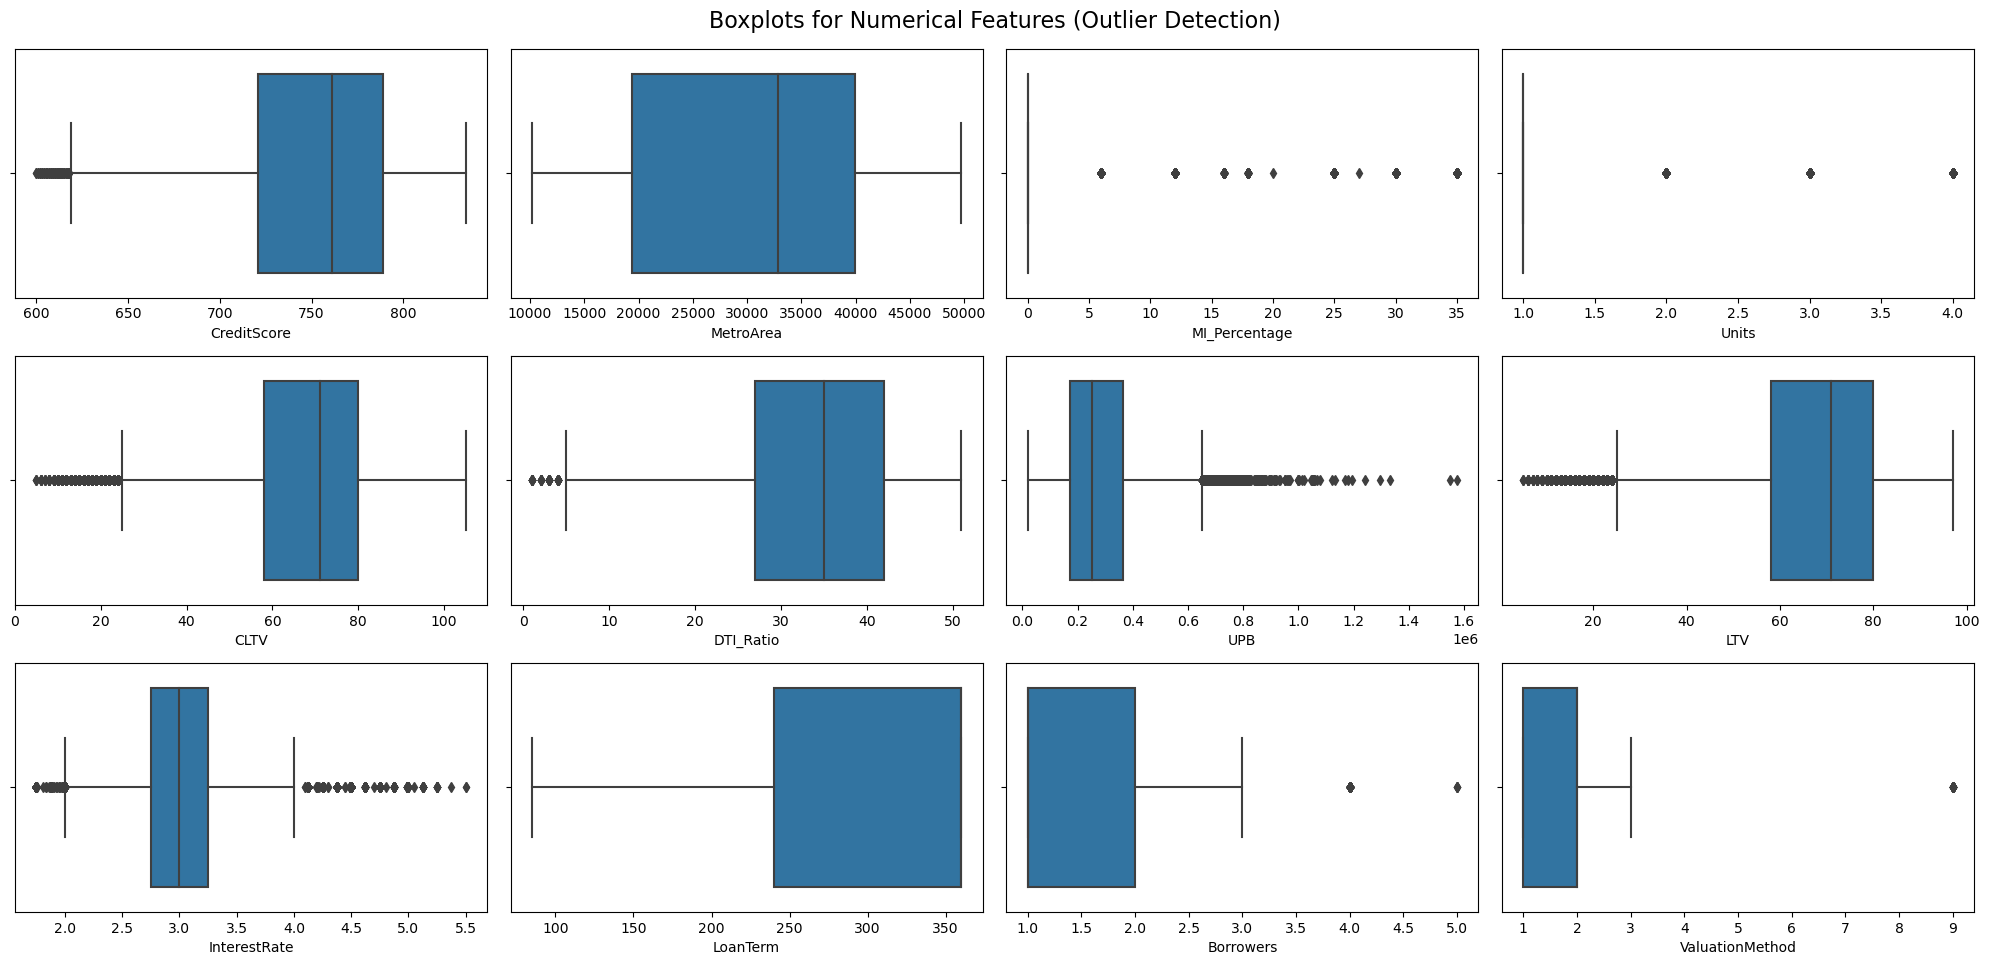

In [16]:
# Explore
num_cols = historic_df.select_dtypes(include=['int64', 'float64']).drop(columns=['DefaultFlag']).columns


#  Visualize boxplots for numerical columns
plt.figure(figsize=(20, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data=historic_df, x=col)
    plt.tight_layout()
plt.suptitle('Boxplots for Numerical Features (Outlier Detection)', fontsize=16, y=1.02)
plt.show()

In [17]:

# IQR filter
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

iqr_cols = ['UPB','InterestRate','MI_Percentage','CLTV','LTV']

for col in iqr_cols:
    historic_df = remove_outliers_iqr(historic_df, col)


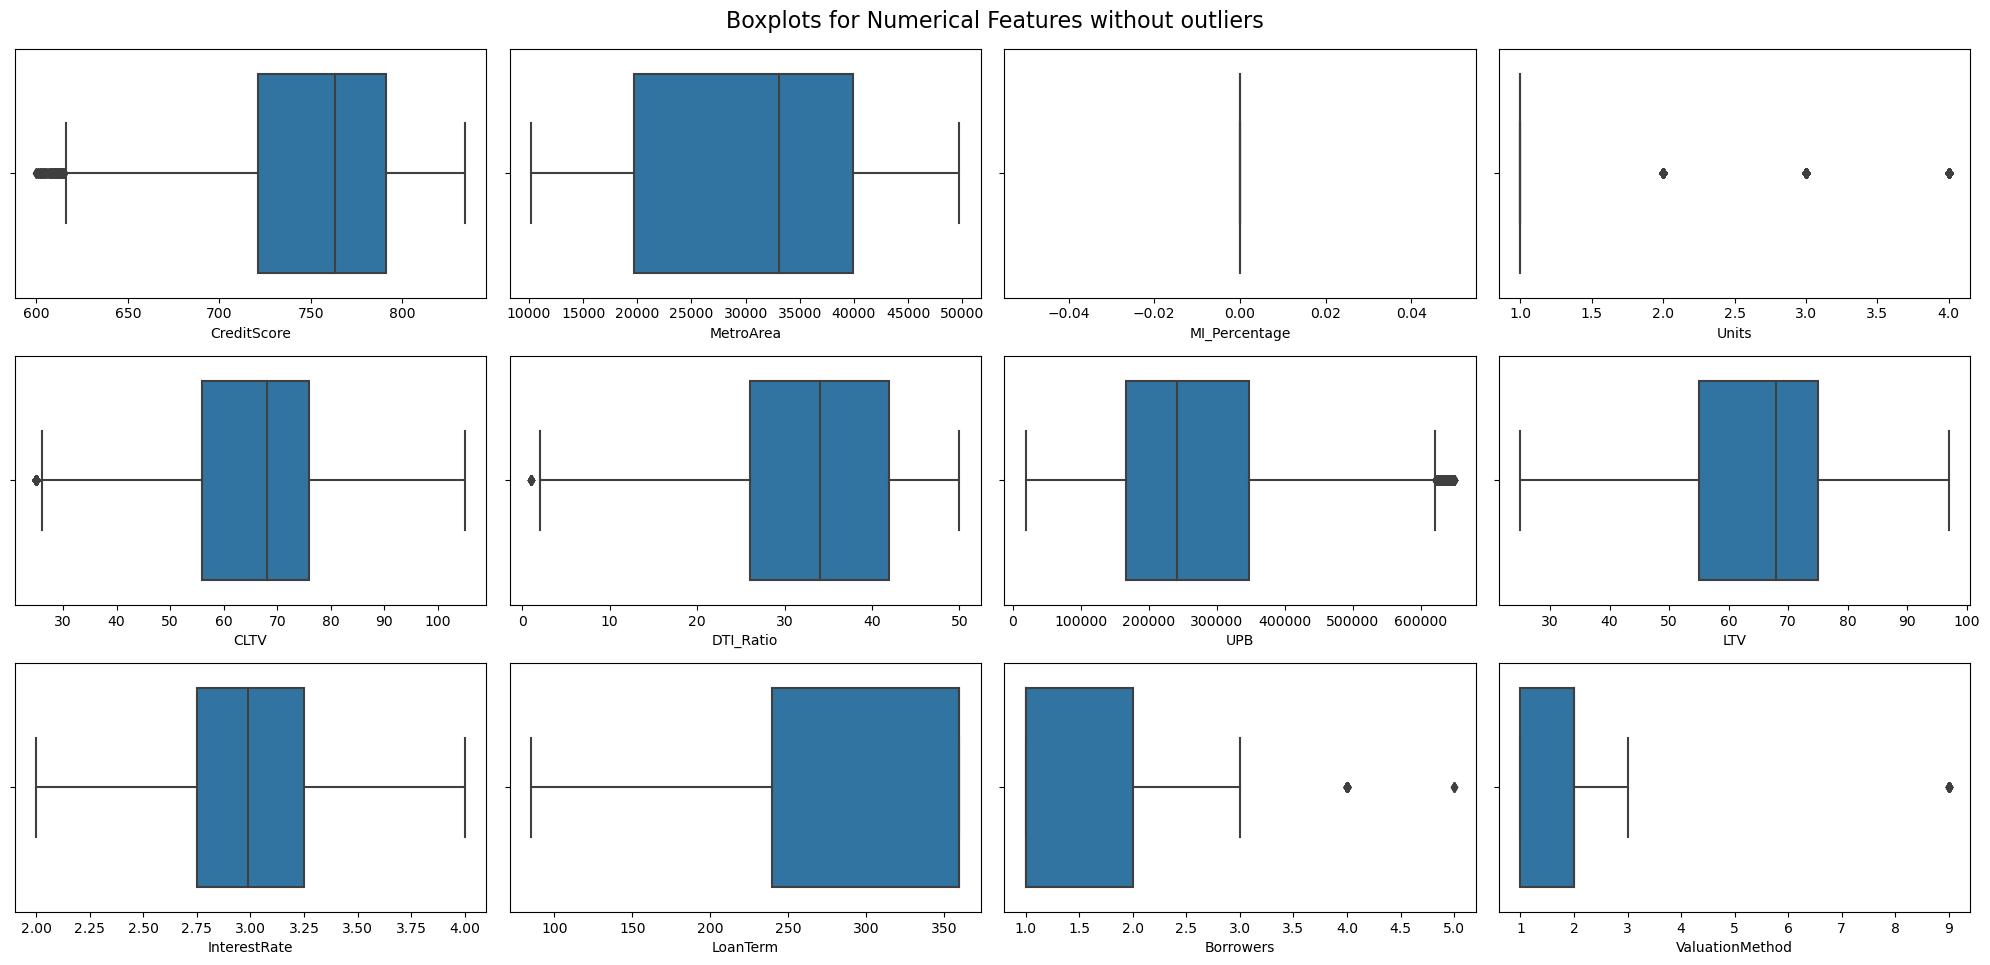

In [18]:
#   boxplots for numerical with out outlirs
plt.figure(figsize=(20, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data=historic_df, x=col)
    plt.tight_layout()
plt.suptitle('Boxplots for Numerical Features without outliers', fontsize=16, y=1.02)
plt.show()

In [19]:
categorical_cols = historic_df.select_dtypes(include='object').columns.tolist()
categorical_cols

['FirstHomebuyer', 'Occupancy', 'State', 'PropertyType', 'LoanPurpose']

In [20]:
num_cols

Index(['CreditScore', 'MetroArea', 'MI_Percentage', 'Units', 'CLTV',
       'DTI_Ratio', 'UPB', 'LTV', 'InterestRate', 'LoanTerm', 'Borrowers',
       'ValuationMethod'],
      dtype='object')

In [21]:
selected_feature = [list(categorical_cols) + list(num_cols)]
selected_feature

[['FirstHomebuyer',
  'Occupancy',
  'State',
  'PropertyType',
  'LoanPurpose',
  'CreditScore',
  'MetroArea',
  'MI_Percentage',
  'Units',
  'CLTV',
  'DTI_Ratio',
  'UPB',
  'LTV',
  'InterestRate',
  'LoanTerm',
  'Borrowers',
  'ValuationMethod']]

In [22]:
# encoder
historic_df_encoded = pd.get_dummies(historic_df, columns=categorical_cols, drop_first=True)

In [23]:
historic_df_encoded.columns

Index(['CreditScore', 'MetroArea', 'MI_Percentage', 'Units', 'CLTV',
       'DTI_Ratio', 'UPB', 'LTV', 'InterestRate', 'LoanTerm', 'Borrowers',
       'ValuationMethod', 'DefaultFlag', 'FirstHomebuyer_Y', 'Occupancy_P',
       'Occupancy_S', 'State_AL', 'State_AR', 'State_AZ', 'State_CA',
       'State_CO', 'State_CT', 'State_DC', 'State_DE', 'State_FL', 'State_GA',
       'State_HI', 'State_IA', 'State_ID', 'State_IL', 'State_IN', 'State_KS',
       'State_KY', 'State_LA', 'State_MA', 'State_MD', 'State_ME', 'State_MI',
       'State_MN', 'State_MO', 'State_MS', 'State_MT', 'State_NC', 'State_ND',
       'State_NE', 'State_NH', 'State_NJ', 'State_NM', 'State_NV', 'State_NY',
       'State_OH', 'State_OK', 'State_OR', 'State_PA', 'State_PR', 'State_RI',
       'State_SC', 'State_SD', 'State_TN', 'State_TX', 'State_UT', 'State_VA',
       'State_VT', 'State_WA', 'State_WI', 'State_WV', 'State_WY',
       'PropertyType_CP', 'PropertyType_MH', 'PropertyType_PU',
       'PropertyType_SF', 

In [24]:
X = historic_df_encoded.drop('DefaultFlag', axis=1)
Y = historic_df_encoded['DefaultFlag']

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Scale
scaler = StandardScaler()
sX_train = scaler.fit_transform(X_train)
sX_test = scaler.transform(X_test)

# Grid search
n = 5
param_grid ={'penalty':['l1','l2','elasticnet'],
             'l1_ratio':np.linspace(0,1,n),
             'C':np.logspace(0,10,n)
            }


In [26]:
# model
model = LogisticRegression()
modelGS = GridSearchCV(model,param_grid=param_grid)
modelGS.fit(sX_train,Y_train)


GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e+00, 3.16227766e+02, 1.00000000e+05, 3.16227766e+07,
       1.00000000e+10]),
                         'l1_ratio': array([0.  , 0.25, 0.5 , 0.75, 1.  ]),
                         'penalty': ['l1', 'l2', 'elasticnet']})

In [27]:
print('Best Parameters: ', modelGS.best_params_)

Best Parameters:  {'C': 316.22776601683796, 'l1_ratio': 0.0, 'penalty': 'l2'}


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = modelGS.predict(sX_test)
y_pred_proba = modelGS.predict_proba(sX_test)[:, 1]

# Show predictions
Yte = pd.DataFrame(Y_test)
Yte['Loan_category'] = modelGS.predict(sX_test)
Yte['Yhat_prob'] = modelGS.predict_proba(sX_test)[:,1]
print('Predictions:')
Yte

Predictions:


,DefaultFlag,Loan_category,Yhat_prob
47729,0.0,1.0,0.522568
179271,0.0,0.0,0.005356
142650,0.0,0.0,0.024251
139173,0.0,0.0,0.000134
44110,1.0,1.0,0.577698
...,...,...,...
87644,0.0,0.0,0.006207
191039,0.0,0.0,0.005637
12245,1.0,1.0,0.531482
52153,0.0,0.0,0.267313


Accuracy Score:  0.9087579471113978
Precision Score:  0.6957390146471372
Recall Score:  0.5475982532751091
Normalized Confustion Matrix:  <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x00000160825AC110>


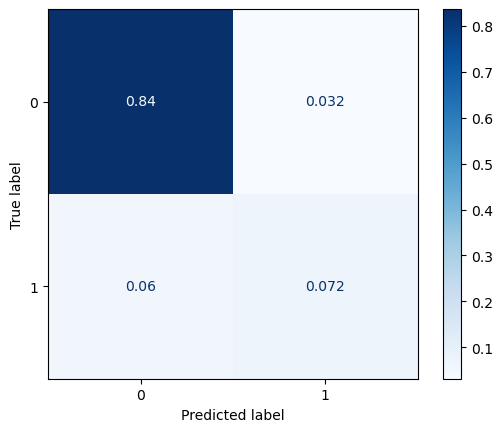

In [29]:

# Performance
print('Accuracy Score: ', accuracy_score(Y_test,y_pred))
print('Precision Score: ', precision_score(Y_test,y_pred))
print('Recall Score: ', recall_score(Y_test,y_pred))


print('Normalized Confustion Matrix: ', ConfusionMatrixDisplay(confusion_matrix(Y_test,y_pred) / confusion_matrix(Y_test,y_pred).sum(),display_labels=[0, 1]).plot(cmap='Blues'))

- Precision (69.6%) tells us how many of the loans we predicted would default actually did default. This matters because we don’t want to reject too many safe loans.

- Recall (54.7%) tells us how many of the actual defaults we correctly caught. 
**Why This Model is the Best Fit:**
1. Logistic regression with regularization avoids overfitting and performs well on both training and test sets
2. Training and prediction are fast, which is ideal for processing large batches of loan applications
3. The model was selected after performing a GridSearchCV over different penalties (l1, l2, elasticnet) and hyperparameters (C, l1_ratio)
4. Class imbalance was acknowledged, and the model ability to recall defaults (true positives)

In [30]:
# Retrain model
# Fit scaler on full data (X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Re-train the best model on full scaled data
final_model = modelGS.best_estimator_
final_model.fit(X_scaled, Y)

final_model = modelGS.best_estimator_
final_model.fit(X_scaled, Y)

# Save model, encoder, and scaler for deployment
dump(final_model, 'models/mortgage/mortgage_default_classifier.joblib')
dump(scaler, 'models/mortgage/mortgage_scaler.joblib')
dump(X.columns.tolist(), 'models/mortgage/mortgage_model_features.joblib')


['models/mortgage/mortgage_model_features.joblib']



Import NewMortages.csv

In the NewMortages.csv dataset, you will find unlabeled data, that is, you will find variables that define characteristics of new mortages that Freddie Mac is considering purchasing, but, because these are new loans, they do not have data on default. Using your models, answer the following questions to help Freddie Mac know what loans to purchase and which loans to not purchase. 

#### 2. [10 Points] Generate a predicted classification for each mortage in the new dataset. What do you predict will be the overall default rate if you buy all the mortages (Report the mean of the predicted default probability for this)?

In [31]:
# deployment components
model = load('models/mortgage/mortgage_default_classifier.joblib')
scaler = load('models/mortgage/mortgage_scaler.joblib')
expected_columns = load('models/mortgage/mortgage_model_features.joblib')


In [32]:
NewMortages_df = pd.read_csv("NewMortages.csv")


In [33]:
NewMortages_df.columns

Index(['Credit.Score', 'First.Payment.Date', 'First.Time.Homebuyer.Flag',
       'Maturity.Date',
       'Metropolitan.Statistical.Area..MSA..Or.Metropolitan.Division',
       'Mortgage.Insurance.Percentage..MI...', 'Number.of.Units',
       'Occupancy.Status', 'Original.Combined.Loan.to.Value..CLTV.',
       'Original.Debt.to.Income..DTI..Ratio', 'Original.UPB',
       'Original.Loan.to.Value..LTV.', 'Original.Interest.Rate',
       'Property.State', 'Property.Type', 'Postal.Code',
       'Loan.Sequence.Number', 'Loan.Purpose', 'Original.Loan.Term',
       'Number.of.Borrowers', 'Seller.Name', 'Servicer.Name',
       'Program.Indicator', 'Property.Valuation.Method'],
      dtype='object')

In [34]:
# Feature matching
NewMortages_df.rename(columns={
    'Credit.Score': 'CreditScore',
    'First.Time.Homebuyer.Flag': 'FirstHomebuyer',
    'Metropolitan.Statistical.Area..MSA..Or.Metropolitan.Division': 'MetroArea',
    'Mortgage.Insurance.Percentage..MI...': 'MI_Percentage',
    'Number.of.Units': 'Units',
    'Occupancy.Status': 'Occupancy',
    'Original.Combined.Loan.to.Value..CLTV.': 'CLTV',
    'Original.Debt.to.Income..DTI..Ratio': 'DTI_Ratio',
    'Original.UPB': 'UPB',
    'Original.Loan.to.Value..LTV.': 'LTV',
    'Original.Interest.Rate': 'InterestRate',
    'Property.State': 'State',
    'Property.Type': 'PropertyType',
    'Postal.Code': 'ZipCode',
    'Loan.Sequence.Number': 'LoanID',
    'Loan.Purpose': 'LoanPurpose',
    'Original.Loan.Term': 'LoanTerm',
    'Number.of.Borrowers': 'Borrowers',
    'Seller.Name': 'Seller',
    'Servicer.Name': 'Servicer',
    'Program.Indicator': 'Program',
    'Property.Valuation.Method': 'ValuationMethod'
}, inplace=True)

In [35]:
NewMortages_df.columns

Index(['CreditScore', 'First.Payment.Date', 'FirstHomebuyer', 'Maturity.Date',
       'MetroArea', 'MI_Percentage', 'Units', 'Occupancy', 'CLTV', 'DTI_Ratio',
       'UPB', 'LTV', 'InterestRate', 'State', 'PropertyType', 'ZipCode',
       'LoanID', 'LoanPurpose', 'LoanTerm', 'Borrowers', 'Seller', 'Servicer',
       'Program', 'ValuationMethod'],
      dtype='object')

In [36]:
NewMortages_df.isnull().sum()

CreditScore              0
First.Payment.Date       0
FirstHomebuyer           0
Maturity.Date            0
MetroArea             4133
MI_Percentage            0
Units                    0
Occupancy                0
CLTV                     0
DTI_Ratio                0
UPB                      0
LTV                      0
InterestRate             0
State                    0
PropertyType             0
ZipCode                  0
LoanID                   0
LoanPurpose              0
LoanTerm                 0
Borrowers                0
Seller                   0
Servicer                 0
Program                  0
ValuationMethod          0
dtype: int64

In [37]:
# drop na
NewMortages_df = NewMortages_df.dropna(subset=['MetroArea'])

In [38]:
#  unnecessary columns
NewMortages = NewMortages_df.drop(columns=columns_to_drop, errors='ignore')

# Encode categorical columns
X_new_encoded = pd.get_dummies(NewMortages)

# Align new data with expected columns
X_new_aligned = X_new_encoded.reindex(columns=expected_columns, fill_value=0)

# Scale features
X_new_scaled = scaler.transform(X_new_aligned)

In [39]:
# Predict default probabilities
y_pred_prob = model.predict_proba(X_new_scaled)[:,1]
y_pred_class = model.predict(X_new_scaled)

#  results
NewMortages_df['Default_Prob']= y_pred_prob
NewMortages_df['Default_Pred'] = y_pred_class


In [40]:

#  results
NewMortages_df['Default_Prob'] = y_pred_prob
NewMortages_df['Default_Pred'] = y_pred_class
overall_default_rate = NewMortages_df['Default_Pred'].mean()
mean_predicted_default_prob = NewMortages_df['Default_Prob'].mean()

print(f"Predicted Overall Default Rate if Freddie Mac buys all the mortgages: {overall_default_rate:.2%}")
print(" Mean of Predicted Default Probabilities: {:.2f}%".format(mean_predicted_default_prob * 100))


Predicted Overall Default Rate if Freddie Mac buys all the mortgages: 17.29%
 Mean of Predicted Default Probabilities: 19.32%


In [41]:

NewMortages = NewMortages_df.reset_index()[['LoanID','CreditScore','DTI_Ratio','LTV','UPB','InterestRate','LoanTerm','Default_Prob', 'Default_Pred']]
NewMortages 

,LoanID,CreditScore,DTI_Ratio,LTV,UPB,InterestRate,LoanTerm,Default_Prob,Default_Pred
0,F21Q20000010,787,46,80,307000,2.875,360,0.720714,1.0
1,F21Q20000068,820,15,59,146000,2.625,360,0.000005,0.0
2,F21Q20000084,781,28,73,92000,2.500,360,0.001417,0.0
3,F21Q20000088,801,40,80,416000,2.750,360,0.258730,0.0
4,F21Q20000091,802,46,72,135000,3.500,360,0.541563,1.0
...,...,...,...,...,...,...,...,...,...
43887,F21Q20963808,798,45,80,106000,4.625,360,0.592237,1.0
43888,F21Q20963836,804,38,80,318000,3.125,360,0.174042,0.0
43889,F21Q20963901,791,21,75,98000,3.125,180,0.000112,0.0
43890,F21Q20963968,748,16,71,110000,3.125,360,0.000025,0.0




#### 3. [5 Points] Assume you want to approve as many loans as possible but maintain an over all default rate of no greater than 7%. Generate a variable that labels what mortages will be purchased and which ones will not. (You may need to create a predicted probability of default and use some threshold of predicted probability to answer this question.) How many loans would you purchase and how many would you reject?



In [42]:
# Sort by lowerr Default_Prob
Newmortages_sorted = NewMortages.sort_values(by='Default_Prob')

In [43]:
# Approve loans while average default rate <= 7%
Newmortages_sorted['Approve'] = 0
approved_defaults = 0
approved_loans = 0

for index, row in Newmortages_sorted.iterrows():
    temp_defaults = approved_defaults + row['Default_Prob']
    temp_loans = approved_loans + 1
    temp_avg = temp_defaults / temp_loans

    if temp_avg <= 0.07:
        Newmortages_sorted.loc[index, 'Approve'] = 1
        approved_defaults = temp_defaults
        approved_loans = temp_loans
    else:
        break

In [44]:
# decisions
Newmortages_sorted['Decision'] = Newmortages_sorted['Approve'].map({1: 'Purchase', 0: 'Do Not Purchase'})

In [45]:
approved_df = Newmortages_sorted[Newmortages_sorted['Approve'] == 1]
avg_default_rate = approved_df['Default_Prob'].mean()
total_approved = approved_df.shape[0]
total_rejected = Newmortages_sorted.shape[0] - total_approved
Newmortages_sorted

,LoanID,CreditScore,DTI_Ratio,LTV,UPB,InterestRate,LoanTerm,Default_Prob,Default_Pred,Approve,Decision
19643,F21Q20436836,783,4,24,162000,2.375,180,3.369883e-09,0.0,1,Purchase
10383,F21Q20235371,809,9,14,193000,2.750,180,6.622721e-09,0.0,1,Purchase
7878,F21Q20179529,798,6,24,174000,2.250,180,6.682877e-09,0.0,1,Purchase
41989,F21Q20919693,807,9,10,52000,2.990,360,7.595734e-09,0.0,1,Purchase
8753,F21Q20199422,806,8,19,87000,2.875,120,7.847277e-09,0.0,1,Purchase
...,...,...,...,...,...,...,...,...,...,...,...
21689,F21Q20482694,765,50,95,684000,3.125,360,9.963910e-01,1.0,0,Do Not Purchase
35513,F21Q20780915,736,50,95,556000,3.250,360,9.969268e-01,1.0,0,Do Not Purchase
21564,F21Q20479879,716,999,60,165000,4.500,360,1.000000e+00,1.0,0,Do Not Purchase
2332,F21Q20056471,784,999,59,277000,2.550,240,1.000000e+00,1.0,0,Do Not Purchase


In [46]:
# approve loans
approved_df.to_csv('Report/Approved_Loans.csv', index=False)

In [47]:
# Result
print(f"Loans Approved (Purchased): {total_approved}")
print(f"Loans Rejected (Not Purchased): {total_rejected}")
print(f"Final Average Default Rate of Approved Loans: {avg_default_rate:.2%}")
Newmortages_sorted

Loans Approved (Purchased): 35895
Loans Rejected (Not Purchased): 7997
Final Average Default Rate of Approved Loans: 7.00%


,LoanID,CreditScore,DTI_Ratio,LTV,UPB,InterestRate,LoanTerm,Default_Prob,Default_Pred,Approve,Decision
19643,F21Q20436836,783,4,24,162000,2.375,180,3.369883e-09,0.0,1,Purchase
10383,F21Q20235371,809,9,14,193000,2.750,180,6.622721e-09,0.0,1,Purchase
7878,F21Q20179529,798,6,24,174000,2.250,180,6.682877e-09,0.0,1,Purchase
41989,F21Q20919693,807,9,10,52000,2.990,360,7.595734e-09,0.0,1,Purchase
8753,F21Q20199422,806,8,19,87000,2.875,120,7.847277e-09,0.0,1,Purchase
...,...,...,...,...,...,...,...,...,...,...,...
21689,F21Q20482694,765,50,95,684000,3.125,360,9.963910e-01,1.0,0,Do Not Purchase
35513,F21Q20780915,736,50,95,556000,3.250,360,9.969268e-01,1.0,0,Do Not Purchase
21564,F21Q20479879,716,999,60,165000,4.500,360,1.000000e+00,1.0,0,Do Not Purchase
2332,F21Q20056471,784,999,59,277000,2.550,240,1.000000e+00,1.0,0,Do Not Purchase


##### Loan Approval Strategy (Under 7% requirement)
To maximize the number of mortgage purchases while maintaining an overall predicted default rate under 7%:

1. Sorted all loans by predicted default probability **(Default_Prob)**.
2. Approved loans one by one until the **average default probability of approved loans reached  7%**.
3. Rejected all remaining loans.

**Final Stats:**
- Total Loans Evaluated: 43,892
- Loans Approved: 35,895
- Loans Rejected: 7,997
- Average Default Rate of Approved Loans: 7.00%


#### 4. [5 Points] Finally, optimize the the acceptance decision so that you maximize profits, instead of trying to set the overall default rate.

#####   4.1.  Calculate the expected profit for each loan. "Expected profit" means the probability that the loan is repaid times the profit earned if repaid plus the probability that the loan is not repaid times the profit if the loan is not repaid. Assume that the loan is repaid using a standard amortized loan repayment structure with the principle provided in the Original.UPB, using the monthly interest rate provided in the interest rate variable, for a duration of the loan (in months) provided in the duration variable. An equation for how to calculate the monthly payment for such a loan can be found here: https://www.calculatorsoup.com/calculators/financial/loan-calculator.php. Assume that the bank must buy the loan for the cost of the principle (so they incure that cost regardless of whether the loan is repaid). Also assume that if someone defaults that they default entirely so nothing is repaid in that case (I admit that this is an extreme assumption).

        Expected Profit $= (1-Pr(default))*Profit If Loan Repaid + Pr(default)*Profit If Loan Default$





In [48]:
Newmortages_sorted.columns

Index(['LoanID', 'CreditScore', 'DTI_Ratio', 'LTV', 'UPB', 'InterestRate',
       'LoanTerm', 'Default_Prob', 'Default_Pred', 'Approve', 'Decision'],
      dtype='object')

In [49]:
Newmortages_df = Newmortages_sorted.copy()

#  monthly payment
def calculate_monthly_payment(principal, annual_rate, months):
    monthly_rate = (annual_rate / 12) / 100  # Convert annual rate to monthly decimal
    return principal * ((monthly_rate * (1 + monthly_rate)**months) / ((1 + monthly_rate)**months - 1))

#  profit if loan is repaid
def calculate_profit_if_repaid(principal, monthly_payment, months):
    total_repaid = monthly_payment * months  
    return total_repaid - principal  

In [50]:
# expected profit for each loan

def calculate_expected_profits(dataframe):
    profits = []  # Store expected profits
    for index, row in dataframe.iterrows():
        #  loan parameters
        principal = row['UPB']
        annual_rate = row['InterestRate']
        months = row['LoanTerm']
        default_prob = row['Default_Prob']
        
        #  monthly payment
        monthly_payment = calculate_monthly_payment(principal, annual_rate, months)
        
        #  profit if repaid
        profit_if_repaid = calculate_profit_if_repaid(principal, monthly_payment, months)
        
        # Profit if defaulted 
        profit_if_default = -principal
        
        #  expected profit
        expected_profit = ((1 - default_prob) * profit_if_repaid) + (default_prob * profit_if_default)
        profits.append(expected_profit)
        
    return profits

In [51]:
Newmortages_df['Expected_Profit'] = calculate_expected_profits(Newmortages_df)


In [52]:
Newmortages_df['Decision'] = Newmortages_df['Expected_Profit'].apply(lambda x: 'Purchase' if x > 0 else 'Do Not Purchase')

In [53]:
Newmortages_df = Newmortages_df.sort_values(by='Expected_Profit', ascending=False)
Newmortages_df

,LoanID,CreditScore,DTI_Ratio,LTV,UPB,InterestRate,LoanTerm,Default_Prob,Default_Pred,Approve,Decision,Expected_Profit
2367,F21Q20057151,794,30,44,1053000,3.500,360,0.001728,0.0,1,Purchase,646297.178112
32058,F21Q20704023,709,14,70,1022000,3.500,360,0.000053,0.0,1,Purchase,630037.548975
18194,F21Q20405539,776,19,75,928000,3.625,360,0.000359,0.0,1,Purchase,595028.747143
42049,F21Q20921082,720,38,31,822000,3.990,360,0.006875,0.0,1,Purchase,579360.174482
28350,F21Q20624349,750,39,45,1034000,3.500,360,0.044065,0.0,1,Purchase,563868.063161
...,...,...,...,...,...,...,...,...,...,...,...,...
3590,F21Q20085016,762,50,89,822000,3.125,360,0.993796,1.0,0,Do Not Purchase,-814135.974141
2369,F21Q20057162,810,47,80,944000,3.450,360,0.923494,1.0,0,Do Not Purchase,-827973.515362
19473,F21Q20433311,652,45,80,940000,3.625,360,0.955195,1.0,0,Do Not Purchase,-870852.725267
40562,F21Q20888703,806,45,78,1053000,3.250,360,0.953240,1.0,0,Do Not Purchase,-975856.990662


In [54]:
# save 
Newmortages_df.to_csv('Report/Loans_Optimized_For_Profit.csv', index=False)

 
      
#####  4.2.  When you are maximizing profits, What will your profits be, how many loans will you approve, and what is the loan repayment probability cutoff that you used to optimize profits?
    

In [55]:
# approved loans
approved_loans_df = Newmortages_df[Newmortages_df['Decision'] == 'Purchase']

# total profits
total_profits = approved_loans_df['Expected_Profit'].sum()

# count approved loans
total_approved_loans = approved_loans_df.shape[0]

# repayment probability cutoff
repayment_probability_cutoff = 1 - approved_loans_df['Default_Prob'].max()

print(f"Total Profits: ${total_profits:,.2f}")
print(f"Number of Approved Loans: {total_approved_loans}")
print(f"Repayment Probability Cutoff: {repayment_probability_cutoff:.2%}")


Total Profits: $3,623,145,801.16
Number of Approved Loans: 33476
Repayment Probability Cutoff: 54.94%


#####  4.3.  If you were a policy maker who wanted to implement a policy that keeps banks from assuming too much risk, porfolio risk in excess of 7%, would you need to impose a portfolio risk limit in this case? That is, would you need to 'regulate' Feddie Mac to keep them from assuming too much risk?
    

In [56]:

# portfolio risk (average default probability of approved loans)
portfolio_risk = approved_loans_df['Default_Prob'].mean()


print(f"Portfolio Risk (Average Default Probability): {portfolio_risk:.2%}")

if portfolio_risk > 0.07:  
    print(" Portfolio risk exceeds 7%! Regulatory intervention may be necessary.")
else:
    print("Portfolio risk is within acceptable limits. No regulation needed.")


Portfolio Risk (Average Default Probability): 4.82%
Portfolio risk is within acceptable limits. No regulation needed.


#####  4.4.  Let's say that we want to increase access to affordable housing. We could increase access to housing by subsidizing the mortage market. If Freddie Mac can buy mortages at a reduced price, then perhaps they could buy more mortages which would create an incentive for banks to offer more mortages; this would make it easier for people to buy homes. So let's subsidize the cost of purchasing a mortage by saying that the government will cover 40% of the cost of the mortages that Freddie Mac purchases. Maximize the profits again. What are the profits, number of loans purchased, and the default rate at the new subsidized optimal?
   

In [57]:

# profit if the loan is repaid
def calculate_subsidized_profit_if_repaid(principal, monthly_payment, months):
    total_repaid = monthly_payment * months  # Total repayment amount
    subsidized_cost = 0.6 * principal  # Freddie Mac pays only 60% of the principal
    return total_repaid - subsidized_cost  # Profit = Total repaid - Subsidized cost

# expected profit with subsidy
def calculate_expected_profits_with_subsidy(dataframe):
    profits = []  # Store expected profits
    for index, row in dataframe.iterrows():
        # Extract loan parameters
        principal = row['UPB']
        annual_rate = row['InterestRate']
        months = row['LoanTerm']
        default_prob = row['Default_Prob']
        
        # Calculate monthly payment
        monthly_payment = calculate_monthly_payment(principal, annual_rate, months)
        
        # Calculate profit if repaid
        profit_if_repaid = calculate_subsidized_profit_if_repaid(principal, monthly_payment, months)
        
        # Profit if defaulted (Freddie Mac only loses 60% of the principal)
        profit_if_default = -(0.6 * principal)
        
        # Calculate expected profit
        expected_profit = ((1 - default_prob) * profit_if_repaid) + (default_prob * profit_if_default)
        profits.append(expected_profit)
        
    return profits

In [58]:
# expected profits for all loans with subsidy
Newmortages_df['Expected_Profit_Subsidized'] = calculate_expected_profits_with_subsidy(Newmortages_df)


In [59]:
# decisions based on expected profit
Newmortages_df['Decision_Subsidized'] = Newmortages_df['Expected_Profit_Subsidized'].apply(lambda x: 'Purchase' if x > 0 else 'Do Not Purchase')

In [60]:
Newmortages_df = Newmortages_df.sort_values(by='Expected_Profit_Subsidized', ascending=False)

approved_loans_Subsidized_df = Newmortages_df[Newmortages_df['Decision_Subsidized'] == 'Purchase']
total_profits = approved_loans_Subsidized_df['Expected_Profit_Subsidized'].sum()
total_approved_loans = approved_loans_Subsidized_df.shape[0]
portfolio_default_rate = approved_loans_Subsidized_df['Default_Prob'].mean()


In [61]:
# save and report
Newmortages_df.to_csv('Subsidized_Loans_Optimized_For_Profit.csv', index=False)

# Display results
print(f"Total Profits (with subsidy): ${total_profits:,.2f}")
print(f"Number of Loans Purchased: {total_approved_loans}")
print(f"Portfolio Default Rate: {portfolio_default_rate:.2%}")

Total Profits (with subsidy): $7,618,410,118.09
Number of Loans Purchased: 37755
Portfolio Default Rate: 9.33%


         4.5. If we are subsidizing the mortage market as described in 4.D, would it now become necessary to regulate the amount of risk that Freddie Mac takes on in order to keep them from holding a porfolio with default risk higher than 7%?

In [62]:
# portfolio_risk = approved_loans_df['Default_Prob'].mean()
if portfolio_default_rate > 0.07:  
    print(" Portfolio risk surpasses 7% threshold,  Regulatory intervention may be necessary")
else:
    print("Portfolio risk is within acceptable limits. No regulation needed")

 Portfolio risk surpasses 7% threshold,  Regulatory intervention may be necessary


####  5. [5 Points] In 2008, the United States lead the world into a global financial crisis resulting in the 'Great Recession'. The main source of this crisis was that there were too many home mortages that entered into default that it lead to financial institutions going bankrupt. Some argue that the root cause of the problem was that there was too light government regulation of US banks, including Freddie Mac. Others argue that the root cause of the problem was that the government subsidized the mortage industry too much and this lead to excessive risk taking by banks.  

#####  5.1. Explain how machine learning could help banks like Freddie Mac and the US government avoid such crises in the future.
   

1. Machine learning uses old loan data and borrower details to predict which loans are risky. This helps Freddie Mac and the US government choose safer loans and avoid approving risky ones.

2. Machine learning can find early signs that many people may stop paying back loans. It can give quick warnings so Freddie Mac and the government can act before problems get worse.

3. Machine learning helps build a good mix of loans that brings profits while keeping risk low. This protects Freddie Mac and the US government from holding too many bad loans at once.

        
##### 5.2. Using your analysis above, explain how both the lack of regulation and government subsidies of the mortage market could contribute to such a financial crisis.

1. Without strong rules, banks and lenders may approve too many risky loans. They may think the market will always go up. This can lead to many people not paying their loans during hard times.

2. If the government pays part of the loan cost, banks may take bigger risks. They feel safe even with risky loans. This can lead to poor decisions and many defaults.

3. Together, weak rules and too much government help can make banks take too many risks. This creates a dangerous situation where many loans may go bad, leading to a big financial crisis.

In [63]:
#end of Question 2